# NLP Zero to Hero: Arabic NLP Implementation

The notebook follows the "NLP Zero to Hero" video series and implements all six parts on an Arabic corpus from the SANAD dataset:

1. **Tokenization** — tokenizing Arabic text with normalization
2. **Sequencing** — converting tokens to padded numerical sequences
3. **Sentiment / Classification Model** — simple Embedding + Dense classifier
4. **RNN Model** — SimpleRNN for news classification
5. **LSTM Model** — Bidirectional stacked LSTM for improved classification
6. **Text Generation** — LSTM next-word prediction model for Arabic text


## Importing Libraries
Importing all the required libraries:

- **os / zipfile** — for loading and extracting the dataset from Google Drive
- **re** — for Arabic text normalization using regular expressions
- **numpy / pandas** — for numerical operations and data handling
- **matplotlib** — for plotting training curves
- **sklearn** — for label encoding and train/validation splitting
- **tensorflow / keras** — for building and training all deep learning models

In [ ]:
import os
import zipfile
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Embedding, Dense, GlobalAveragePooling1D,
    SimpleRNN, LSTM, Bidirectional
)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Loading and Extracting the SANAD Dataset

The SANAD dataset is stored as a nested ZIP file. This cell:
1. Extracts the main ZIP from Google Drive into `/content/SANAD/`
2. Scans for any inner ZIP files and extracts them as well
3. Prints the resulting folder structure for verification

SANAD is organized by news source, and within each source, articles are grouped into category subfolders. Each article is stored as a `.txt` file.

In [ ]:
zip_path = '/content/drive/MyDrive/NLP Assignment2/SANAD.zip'
main_path = "/content/SANAD"

# ensure destination folder exists
os.makedirs(main_path, exist_ok=True)

# the "-q" flag keeps the output quiet (no verbose extraction log)
!unzip -q "/content/drive/MyDrive/NLP Assignment2/SANAD.zip" -d "/content/SANAD"

# loop through the extracted files and look for any nested zip files
for zip_name in os.listdir(main_path):
    if zip_name.endswith(".zip"):
        # get the full path to the nested zip file
        inner_zip_path = os.path.join(main_path, zip_name)
        extract_dir = os.path.join(main_path, zip_name.replace(".zip", ""))
        print("extracting:", inner_zip_path)
        # open and extract the nested zip file
        with zipfile.ZipFile(inner_zip_path, 'r') as zip_ref:
            zip_ref.extractall(extract_dir)

print("all extracted folders in /content/sanad:", os.listdir(main_path))


extracting: /content/SANAD/Akhbarona.zip
extracting: /content/SANAD/Khaleej.zip
extracting: /content/SANAD/SANAD_SUBSET.zip
extracting: /content/SANAD/Arabiya.zip
all extracted folders in /content/sanad: ['Akhbarona.zip', 'Akhbarona', 'SANAD_SUBSET', 'Khaleej.zip', 'SANAD_SUBSET.zip', 'Arabiya.zip', 'Khaleej', 'Arabiya']


## Building the Corpus and Labels

SANAD contains multiple Arabic news sources: Arabiya, Akhbarona, Khaleej, and SANAD_SUBSET. This cell:
1. Iterates through each source folder and its category subfolders
2. Reads every `.txt` article file
3. Caps each category at **3,000 articles** to keep training time manageable
4. Builds two parallel lists: `corpus` (article texts) and `labels` (category names)

The result is a labeled dataset ready for preprocessing.

In [ ]:
#building corpus and labels from sanad folder structure
corpus = []
labels = []

#the top-level sources that usually exist in sanad
possible_sources = ['Arabiya', 'Akhbarona', 'Khaleej', 'SANAD_SUBSET']

for source in possible_sources:
    source_path = os.path.join(main_path, source)
    if not os.path.isdir(source_path):
        continue

    print("scanning source folder:", source_path)

    # iterate over categories inside each source
    for category in os.listdir(source_path):
        category_path = os.path.join(source_path, category)
        if not os.path.isdir(category_path):
            continue

        texts_in_category = []
        for fname in os.listdir(category_path):
            fpath = os.path.join(category_path, fname)
            if os.path.isfile(fpath) and fname.lower().endswith('.txt'):
                try:
                    with open(fpath, 'r', encoding='utf-8', errors='ignore') as f:
                        text = f.read()
                    texts_in_category.append(text)
                except Exception as e:
                    # skip files that cannot be read
                    continue

        #sample a fixed number per category to speed up training
        max_per_category = 3000  # you can reduce or increase depending on gpu time
        if len(texts_in_category) > max_per_category:
            texts_in_category = texts_in_category[:max_per_category]

        corpus.extend(texts_in_category)
        labels.extend([category] * len(texts_in_category))

print("total documents:", len(corpus))
print("total labels:", len(labels))
print("example label distribution (first 10):", labels[:10])
print("sample document:\n", corpus[0][:400])


scanning source folder: /content/SANAD/Arabiya
scanning source folder: /content/SANAD/Akhbarona
scanning source folder: /content/SANAD/Khaleej
scanning source folder: /content/SANAD/SANAD_SUBSET
total documents: 60000
total labels: 60000
example label distribution (first 10): ['Tech', 'Tech', 'Tech', 'Tech', 'Tech', 'Tech', 'Tech', 'Tech', 'Tech', 'Tech']
sample document:
 أعلنت "بورش ديزاين" و"بلاكبيري المحدودة" عن إطلاق النسخة الجديدة من الهاتف الذكي Porsche Design P’9983 من "بلاكبيري". ويجمع هاتف P’9983 الجديد بين فخامة التصميم الإبداعي والفريد من "بورش ديزاين"، مع تجربة تكنولوجيا "بلاكبيري 10" المذهلة في استخدام الهواتف الذكية الراقية والمصممة بمستويات متفوقة في الاتصال والتواصل والإنتاجية أثناء التنقل. ويشكل هذا الهاتف ثمرة التعاون الثالث بين "بلاكبيري" و"بورش 


#Normalization & Tokenization
## Part 1: Arabic Text Normalization and Tokenization

This part corresponds to **Video Part 1: Tokenization** from the NLP Zero to Hero series.

### - Normalization
Arabic text requires specific normalization steps before tokenization. The `normalize_arabic()` function applies the following:

| Step | What it does |
|---|---|
| Remove diacritics | Strips tashkeel marks that add noise without changing word meaning |
| Unify Alef variants | Normalizes إ, أ, آ, ا all to ا |
| Normalize ة to ه | Reduces morphological variation at word endings |
| Normalize ى to ي | Handles alternative Alef Maqsura form |
| Remove Tatweel | Removes the elongation character ـ |
| Keep Arabic only | Removes non-Arabic characters except basic punctuation |
| Normalize whitespace | Collapses multiple spaces into one |

### - Tokenization
We use Keras `Tokenizer` with a vocabulary limit of **20,000 words** and an `<OOV>` token to handle out-of-vocabulary words that appear during evaluation but were not seen during training.

**Challenges with Arabic tokenization:**
- Arabic is a morphologically rich language — one root can generate dozens of word forms
- Diacritics and character variants must be normalized first, otherwise the same word appears as multiple different tokens
- Dialects and spelling variations further increase vocabulary size

In [ ]:
def normalize_arabic(text):
    text = str(text)  # ensure input is a string
    text = re.sub(r'[\u0617-\u061A\u064B-\u0652]', '', text)  # Removing diacritics
    text = re.sub('[إأآا]', 'ا', text)# Normalising Alef variants to standard Alef
    text = re.sub(r'ة', 'ه', text) # Normalising ة to ه
    text = re.sub(r'ى', 'ي', text) # Normalising ى to ي
    text = re.sub(r'ـ', '', text) # Removing diacritics (الحركات)
    text = re.sub(r'[^0-9\u0600-\u06FF\s.,؟!؛:()\-]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# apply normalization function to every document in the 'corpus'
normalized_corpus = [normalize_arabic(t) for t in corpus]

print("sample normalized text:\n", normalized_corpus[0][:400])

# tokenization setup
MAX_VOCAB = 20000  # maximum number of words to keep in the vocabulary

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(normalized_corpus) #building vocab with clean corpus

word_index = tokenizer.word_index
print("vocabulary size (unique tokens):", len(word_index))


sample normalized text:
 اعلنت بورش ديزاين و بلاكبيري المحدوده عن اطلاق النسخه الجديده من الهاتف الذكي 9983 من بلاكبيري . ويجمع هاتف 9983 الجديد بين فخامه التصميم الابداعي والفريد من بورش ديزاين ، مع تجربه تكنولوجيا بلاكبيري 10 المذهله في استخدام الهواتف الذكيه الراقيه والمصممه بمستويات متفوقه في الاتصال والتواصل والانتاجيه اثناء التنقل. ويشكل هذا الهاتف ثمره التعاون الثالث بين بلاكبيري و بورش ديزاين ، حيث تمت صناعته باست
vocabulary size (unique tokens): 527901


## Part 2: Sequencing and Padding

This part corresponds to **Video Part 2: Sequencing** from the NLP Zero to Hero series.

Three things happen here:

1. **Sequencing** — each normalized article is converted from text into a list of integer token IDs using the fitted tokenizer
2. **Padding** — all sequences are padded or truncated to a fixed length of **200 tokens** so every input has the same shape for batch training. Post-padding is used, meaning zeros are added to the end of shorter sequences
3. **Label Encoding** — string category names are converted to integer class IDs using `LabelEncoder`

**Why 200 tokens?**
After inspecting the dataset, most articles fall within this length. Longer articles are truncated and shorter ones are padded. This keeps memory usage reasonable without losing too much content.

The output is a feature matrix `X` of shape `(num_articles, 200)` and a label array `y`.

In [ ]:
# convert texts to sequences of integers
sequences = tokenizer.texts_to_sequences(normalized_corpus)

MAX_LEN = 200

# pad sequences
X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

print("shape of X:", X.shape)

# encode string labels to integers
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)
num_classes = len(label_encoder.classes_)

print("number of classes:", num_classes)
print("classes:", list(label_encoder.classes_))


shape of X: (60000, 200)
number of classes: 7
classes: [np.str_('Culture'), np.str_('Finance'), np.str_('Medical'), np.str_('Politics'), np.str_('Religion'), np.str_('Sports'), np.str_('Tech')]


## Splitting into Training and Validation Sets

The dataset is split into:
- **80% training** — used to update model weights
- **20% validation** — used to monitor performance after each epoch

`stratify=y` ensures each category is proportionally represented in both splits, preventing the model from being trained or evaluated on an unbalanced class distribution.

In [ ]:
#splititng data into train and validation sets (80-20)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("train shape:", X_train.shape, "validation shape:", X_val.shape)


train shape: (48000, 200) validation shape: (12000, 200)


## Part 3: "Simple" Sentiment model

This part corresponds to **Video Part 3: Sentiment Model** from the NLP Zero to Hero series.

This is the baseline deep learning classifier. It uses a minimal architecture to establish a performance reference point:

- **Embedding layer** — learns a 64-dimensional vector representation for each word in the vocabulary
- **GlobalAveragePooling1D** — averages all word embeddings in a sequence into a single vector, ignoring word order entirely
- **Dense (64, ReLU)** — a hidden layer for non-linear feature learning
- **Dense (softmax)** — output layer producing a probability distribution over all news categories

This model treats each article as a bag of averaged word vectors. It is fast to train but cannot capture sequential patterns or the order in which words appear.

In [ ]:
EMBED_DIM = 64

model_simple = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM, input_length=MAX_LEN),
    GlobalAveragePooling1D(),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model_simple.compile( #w/ loss func, optimizer, and eval metrics
    loss='sparse_categorical_crossentropy',
    optimizer='adam', #automatically adjusts the learning rate for each weight
    metrics=['accuracy']
)

model_simple.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Training the "Simple" Model

The model is trained for **5 epochs** with a batch size of **128** using:
- **Loss:** Sparse categorical cross-entropy — suitable for integer-encoded multi-class labels
- **Optimizer:** Adam — adaptive learning rate optimizer that works well for NLP tasks
- **Metric:** Accuracy — proportion of correctly classified articles per epoch

Training and validation accuracy and loss are recorded each epoch for later comparison.

In [ ]:
# train the simple model

EPOCHS_SIMPLE = 5
BATCH_SIZE = 128

history_simple = model_simple.fit(
    X_train, y_train,
    epochs=EPOCHS_SIMPLE,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=1
)


Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.5983 - loss: 1.3692 - val_accuracy: 0.9222 - val_loss: 0.3116
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9351 - loss: 0.2470 - val_accuracy: 0.9302 - val_loss: 0.2340
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9563 - loss: 0.1568 - val_accuracy: 0.9423 - val_loss: 0.2003
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9688 - loss: 0.1175 - val_accuracy: 0.9437 - val_loss: 0.1945
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9775 - loss: 0.0877 - val_accuracy: 0.9430 - val_loss: 0.1969


## Visualizing Training Curves

The `plot_history()` function plots training vs. validation accuracy and loss across epochs.

These curves help us diagnose model behavior:
- **Overfitting** — training accuracy much higher than validation accuracy
- **Underfitting** — both curves plateau at a low value
- **Good generalization** — training and validation curves are close and both improving

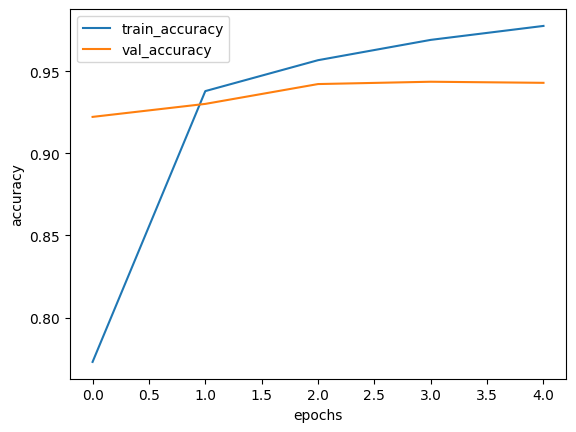

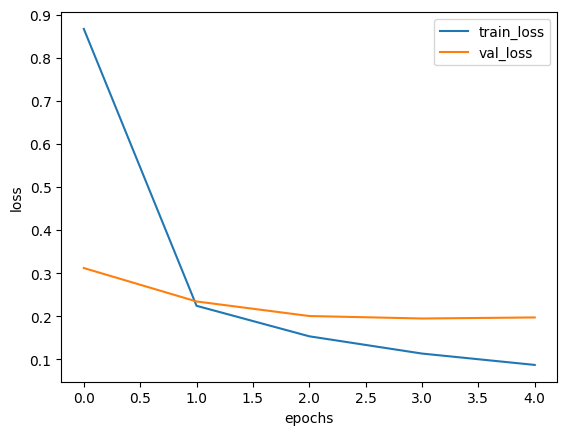

In [ ]:
def plot_history(history, metric='accuracy'):
    # metric can be 'accuracy' or 'loss'
    plt.plot(history.history[metric], label=f'train_{metric}')
    plt.plot(history.history[f'val_{metric}'], label=f'val_{metric}')
    plt.xlabel('epochs')
    plt.ylabel(metric)
    plt.legend()
    plt.show()

# plot accuracy and loss for the simple model
plot_history(history_simple, 'accuracy')
plot_history(history_simple, 'loss')


## Part 4: RNN Model

This part corresponds to **Video Part 4: RNN** from the NLP Zero to Hero series.

Unlike the simple model which averaged word embeddings, this model uses a **SimpleRNN** layer that processes the sequence word-by-word. It maintains a hidden state that carries information forward from each word to the next.

Architecture:
- **Embedding layer** — 64-dimensional word vectors
- **SimpleRNN (64 units)** — processes the sequence left to right, capturing basic sequential dependencies
- **Dense (64, ReLU)** — hidden layer
- **Dense (softmax)** — output layer

**Limitation:** SimpleRNN struggles with long-range dependencies because gradients shrink as they travel back through many time steps — known as the **vanishing gradient problem**. This is the motivation for using LSTM in the next part.

In [ ]:
model_rnn = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM, input_length=MAX_LEN),
    SimpleRNN(64),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model_rnn.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_rnn.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Training the RNN Model

Trained with the same configuration as the simple model — 5 epochs, batch size 128, Adam optimizer — to allow a fair and direct comparison between architectures. The only variable that changes is the model itself.

In [ ]:
EPOCHS_RNN = 5

history_rnn = model_rnn.fit(
    X_train, y_train,
    epochs=EPOCHS_RNN,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=1
)


Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.2086 - loss: 1.8770 - val_accuracy: 0.2387 - val_loss: 1.8465
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.2647 - loss: 1.7753 - val_accuracy: 0.3262 - val_loss: 1.6280
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 19ms/step - accuracy: 0.4107 - loss: 1.4882 - val_accuracy: 0.4446 - val_loss: 1.3879
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.5884 - loss: 1.0296 - val_accuracy: 0.4737 - val_loss: 1.3435
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.6253 - loss: 0.8995 - val_accuracy: 0.4464 - val_loss: 1.5083


## Comparing "Simple" Model vs RNN

We plot the RNN training curves and print the final validation accuracy of both models side by side.

This comparison answers the question: does adding sequential processing (SimpleRNN) improve over treating the article as an unordered bag of word vectors (GlobalAveragePooling)?

For Arabic news classification, word order carries meaningful information about the structure and topic of an article, so the RNN is expected to outperform the simple model.

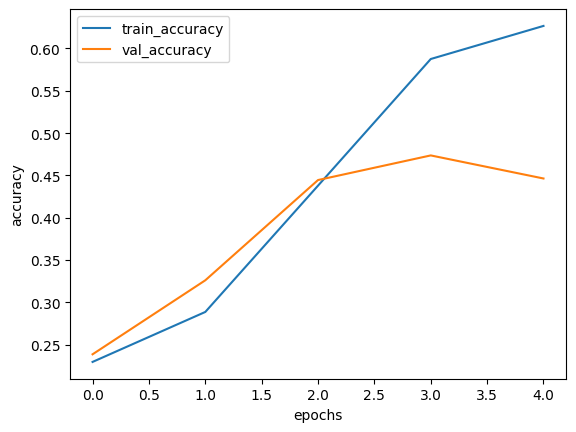

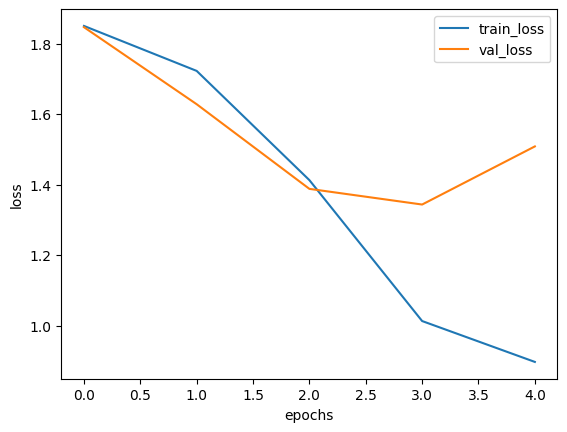


final validation accuracy - simple model: 0.9430000185966492
final validation accuracy - rnn model: 0.4464166760444641


In [ ]:
plot_history(history_rnn, 'accuracy')
plot_history(history_rnn, 'loss')

# final validation accuracies for quick comparison
simple_val_acc = history_simple.history['val_accuracy'][-1]
rnn_val_acc = history_rnn.history['val_accuracy'][-1]

print("\nfinal validation accuracy - simple model:", simple_val_acc)
print("final validation accuracy - rnn model:", rnn_val_acc)


## Part 5: Bidirectional LSTM Model

This part corresponds to **Video Part 5: LSTM** from the NLP Zero to Hero series.

This is the most powerful of the three classification models, using stacked **Bidirectional LSTM** layers to address the limitations of SimpleRNN.

Architecture:
- **Embedding layer** — 64-dimensional word vectors
- **Bidirectional LSTM (64 units, return_sequences=True)** — reads the sequence both left-to-right and right-to-left, then concatenates both representations. Passes the full sequence output to the next layer
- **Bidirectional LSTM (32 units)** — second LSTM layer for deeper representation learning
- **Dense (64, ReLU)** — hidden layer
- **Dense (softmax)** — output layer

**Why Bidirectional?**
A standard LSTM only reads text forward. A Bidirectional LSTM reads in both directions simultaneously — giving each word access to both what came before and what comes after. This is particularly useful for Arabic, where word meaning often depends heavily on surrounding context.

**LSTM vs RNN:**
LSTM uses gating mechanisms (input, forget, output gates) that allow it to selectively remember or forget information over long sequences, directly solving the vanishing gradient problem that SimpleRNN suffers from.

In [ ]:
model_lstm = Sequential([
    Embedding(input_dim=MAX_VOCAB, output_dim=EMBED_DIM, input_length=MAX_LEN),
    Bidirectional(LSTM(64, return_sequences=True)),
    Bidirectional(LSTM(32)),
    Dense(64, activation='relu'),
    Dense(num_classes, activation='softmax')
])

model_lstm.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_lstm.summary()


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Training the Bidirectional LSTM Model

Trained for 5 epochs with the same settings as the previous models for consistency. The BiLSTM has significantly more trainable parameters than the Simple or RNN models, so training takes longer but is expected to produce the highest validation accuracy.

In [ ]:
EPOCHS_LSTM = 5

history_lstm = model_lstm.fit(
    X_train, y_train,
    epochs=EPOCHS_LSTM,
    batch_size=BATCH_SIZE,
    validation_data=(X_val, y_val),
    verbose=1
)


Epoch 1/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 23s 39ms/step - accuracy: 0.6187 - loss: 1.0116 - val_accuracy: 0.9184 - val_loss: 0.2711
Epoch 2/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 39ms/step - accuracy: 0.9496 - loss: 0.1732 - val_accuracy: 0.8874 - val_loss: 0.3903
Epoch 3/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 38ms/step - accuracy: 0.9693 - loss: 0.1110 - val_accuracy: 0.9111 - val_loss: 0.3281
Epoch 4/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.9837 - loss: 0.0599 - val_accuracy: 0.9273 - val_loss: 0.2799
Epoch 5/5
375/375 ━━━━━━━━━━━━━━━━━━━━ 14s 37ms/step - accuracy: 0.9898 - loss: 0.0383 - val_accuracy: 0.9243 - val_loss: 0.3144


## Final Comparison: All Three Classification Models

We plot the BiLSTM training curves and then print the final validation accuracy of all three models:

| Model | Architecture |
|---|---|
| Simple | Embedding + GlobalAveragePooling + Dense |
| RNN | Embedding + SimpleRNN + Dense |
| BiLSTM | Embedding + Bidirectional LSTM x2 + Dense |

This comparison directly shows the performance gain at each level of architectural complexity and justifies the use of BiLSTM as the strongest model for Arabic news classification.

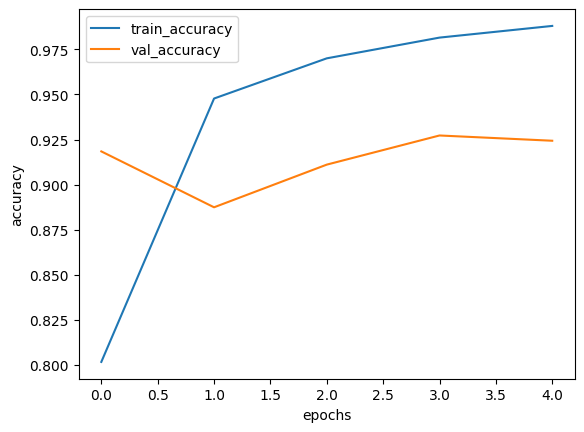

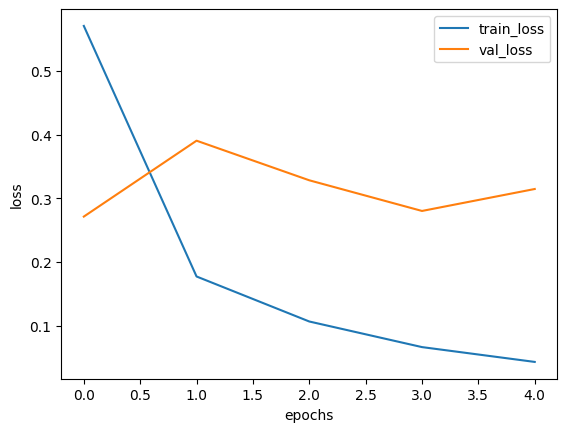


final validation accuracy - simple model: 0.9430000185966492
final validation accuracy - rnn model: 0.4464166760444641
final validation accuracy - lstm model: 0.9243333339691162


In [ ]:
plot_history(history_lstm, 'accuracy')
plot_history(history_lstm, 'loss')

#final validation accuracies for all models
lstm_val_acc = history_lstm.history['val_accuracy'][-1]

print("\nfinal validation accuracy - simple model:", simple_val_acc)
print("final validation accuracy - rnn model:", rnn_val_acc)
print("final validation accuracy - lstm model:", lstm_val_acc)


## Part 6: Preparing Data for Text Generation

This part corresponds to **Video Part 6: Text Generation** from the NLP Zero to Hero series.

We now move from classification to text generation using **next-word prediction**.

The entire normalized corpus is joined into one long text and tokenized into a sequence of integer IDs. We then create sliding window input-output pairs:
- **Input:** a sequence of 20 consecutive tokens
- **Target:** the single token that immediately follows those 20 tokens

This is the standard approach for training a language model. Given the last 20 words of context, the model learns to predict the most likely next word. The result is a very large training set — one pair per token in the entire corpus.

In [ ]:
all_text = " ".join(normalized_corpus)
all_seq = tokenizer.texts_to_sequences([all_text])[0]

print("total number of tokens in combined text:", len(all_seq))

# define sequence length for next-word prediction
SEQ_LEN = 20  # # words in the input sequence

input_sequences = []
targets = []

# create input-output pairs
for i in range(SEQ_LEN, len(all_seq)):
    input_seq = all_seq[i-SEQ_LEN:i]
    target = all_seq[i]
    input_sequences.append(input_seq)
    targets.append(target)

# Convert lists to numpy arrays for model training
input_sequences = np.array(input_sequences)
targets = np.array(targets)

print("input_sequences shape:", input_sequences.shape)
print("targets shape:", targets.shape)


total number of tokens in combined text: 17653318
input_sequences shape: (17653298, 20)
targets shape: (17653298,)


## Text Generation Model: LSTM Next-Word Predictor

This model is separate from the classification models and is dedicated entirely to text generation.

Architecture:
- **Embedding layer** — maps each token ID to a 64-dimensional vector
- **LSTM (128 units)** — learns sequential language patterns from the Arabic news corpus. Larger than the classification LSTMs because text generation requires capturing richer and more nuanced language structure
- **Dense (softmax over full vocabulary)** — outputs a probability for every word in the vocabulary, representing how likely each word is to appear next

The model is trained to minimize cross-entropy loss between its predicted next-word probabilities and the actual next word at each position.

In [ ]:
# an lstm model for next-word prediction
VOCAB_GEN = min(MAX_VOCAB, len(word_index) + 1)

model_gen = Sequential([
    Embedding(input_dim=VOCAB_GEN, output_dim=EMBED_DIM, input_length=SEQ_LEN),
    LSTM(128),
    Dense(VOCAB_GEN, activation='softmax')
])

model_gen.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam'
)

model_gen.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Training the Text Generation Model

The generation model is trained for **3 epochs** with a batch size of **256**.

Fewer epochs are used here because the training set is extremely large — one input-output pair per token in the entire corpus — and even 3 epochs requires significant compute time. The larger batch size speeds up training without sacrificing stability.

In [ ]:
# training the text generation model

EPOCHS_GEN = 3
BATCH_SIZE_GEN = 256

history_gen = model_gen.fit(
    input_sequences,
    targets,
    epochs=EPOCHS_GEN,
    batch_size=BATCH_SIZE_GEN,
    verbose=1
)


Epoch 1/3
68959/68959 ━━━━━━━━━━━━━━━━━━━━ 669s 10ms/step - loss: 5.9902
Epoch 2/3
68959/68959 ━━━━━━━━━━━━━━━━━━━━ 655s 9ms/step - loss: 5.0190
Epoch 3/3
68959/68959 ━━━━━━━━━━━━━━━━━━━━ 652s 9ms/step - loss: 4.9037


## Text Generation with Temperature Sampling

The `generate_text()` function takes a seed sentence in Arabic and generates the next `num_words` words one at a time.

**How it works step by step:**
1. The seed text is normalized using the same function applied during training
2. The text is tokenized and only the last 20 tokens are kept
3. The sequence is padded and passed to the generation model
4. The model outputs a probability distribution over the entire vocabulary
5. **Temperature scaling** is applied before sampling:
   - Temperature < 1.0 — sharpens the distribution, making the model more conservative and predictable
   - Temperature > 1.0 — flattens the distribution, making output more creative and varied
6. A word is sampled from the scaled distribution and appended to the text
7. The loop repeats until the requested number of words is generated

A temperature of **0.8** is used as a balance between coherent Arabic output and natural variation.

In [ ]:
# building reverse index to map ids back to words
index_word = {idx: word for word, idx in word_index.items()}

def generate_text(seed_text, num_words=30, temperature=1.0):
    """
    generate new arabic text given a seed sentence.
    temperature controls randomness:
    - lower (<1.0): more conservative
    - higher (>1.0): more random
    """
    text = normalize_arabic(seed_text)

    for _ in range(num_words):
        # convert current text to sequence
        seq = tokenizer.texts_to_sequences([text])
        # keep only the last seq_len tokens
        seq = [s[-SEQ_LEN:] for s in seq]
        padded = pad_sequences(seq, maxlen=SEQ_LEN, padding='pre')

        # predict probability distribution over next word
        preds = model_gen.predict(padded, verbose=0)[0]

        # apply temperature
        preds = np.asarray(preds).astype('float64')
        preds = np.log(preds + 1e-8) / temperature
        exp_preds = np.exp(preds)
        preds = exp_preds / np.sum(exp_preds)

        # sample from the distribution
        next_index = np.random.choice(range(VOCAB_GEN), p=preds)
        next_word = index_word.get(next_index, '')

        # append next word
        if next_word == '' or next_word == '<OOV>':
            continue
        text += ' ' + next_word

    return text


## Interactive Arabic Text Generation

This cell prompts the user to enter a seed sentence in Arabic. The trained LSTM language model then continues the text by predicting and appending 30 words one at a time.

The output demonstrates that the model has learned the statistical patterns, vocabulary, and flow of Arabic news text. Given a relevant seed sentence, it will generate a contextually related continuation.

This concludes all six parts of the NLP Zero to Hero implementation on the Arabic SANAD corpus.

In [ ]:
user_seed = input("ادخل النص الابتدائي لبدء التوليد: ")

#temperature
user_temp = 0.8

# generate text
generated_text = generate_text(user_seed, num_words=30, temperature=user_temp)

print("\n:النص المُولَّد\n", generated_text)


ادخل النص الابتدائي لبدء التوليد: السعودية

:النص المُولَّد
 السعودية ، وفق ما اوردته صحيفه اخبار اليوم الثلاثاء تمكن عدد من المشاركين الذين تقل المليار سائح معظمهم في 12
